# Pertemuan 4: Statistika Dasar & Analisis Data
### Eksplorasi Statistik Dataset Urus

| | |
|---|---|
| **Nama Lengkap** | Nisa Agustina Maesaroh |
| **NIM** | 240401070509 |
| **Kelas** | IF403 |


In [14]:
#1. Load & Inspect Dataset
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target']
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df = df.drop('target', axis=1)

print('Shape:', df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(3))

Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

In [15]:
#2. Statistik Deskriptif Lengkap
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f'  Mean      : {col.mean():.3f}')
    print(f'  Median    : {col.median():.3f}')
    print(f'  Std Dev   : {col.std():.3f}')
    print(f'  Skewness  : {col.skew():.3f}')
    print(f'  Kurtosis  : {col.kurt():.3f}')


=== sepal_length ===
  Mean      : 5.843
  Median    : 5.800
  Std Dev   : 0.828
  Skewness  : 0.315
  Kurtosis  : -0.552

=== sepal_width ===
  Mean      : 3.057
  Median    : 3.000
  Std Dev   : 0.436
  Skewness  : 0.319
  Kurtosis  : 0.228

=== petal_length ===
  Mean      : 3.758
  Median    : 4.350
  Std Dev   : 1.765
  Skewness  : -0.275
  Kurtosis  : -1.402

=== petal_width ===
  Mean      : 1.199
  Median    : 1.300
  Std Dev   : 0.762
  Skewness  : -0.103
  Kurtosis  : -1.341


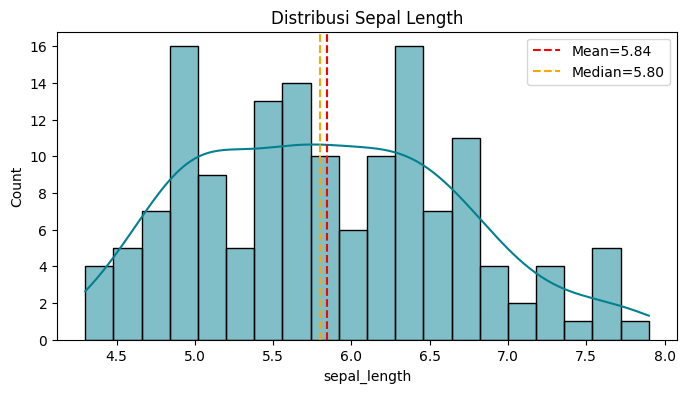

In [16]:
#3. Analisis Distribusi (Histogram + KDE)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True,
color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red',
linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange',
linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length'); ax.legend(); plt.show()

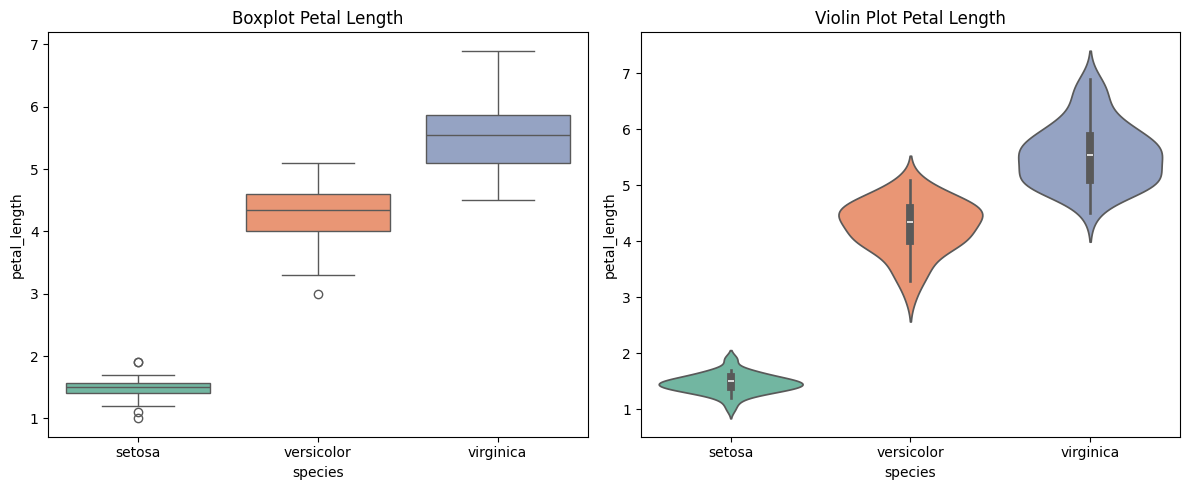

In [17]:
#4. Boxplot per Spesies
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='species', y='petal_length',
            hue='species', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Boxplot Petal Length')
sns.violinplot(data=df, x='species', y='petal_length',
               hue='species', palette='Set2', inner='box', legend=False, ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')
plt.tight_layout()
plt.show()

In [18]:
#5. Matriks Korelasi Pearson
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

import numpy as np
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


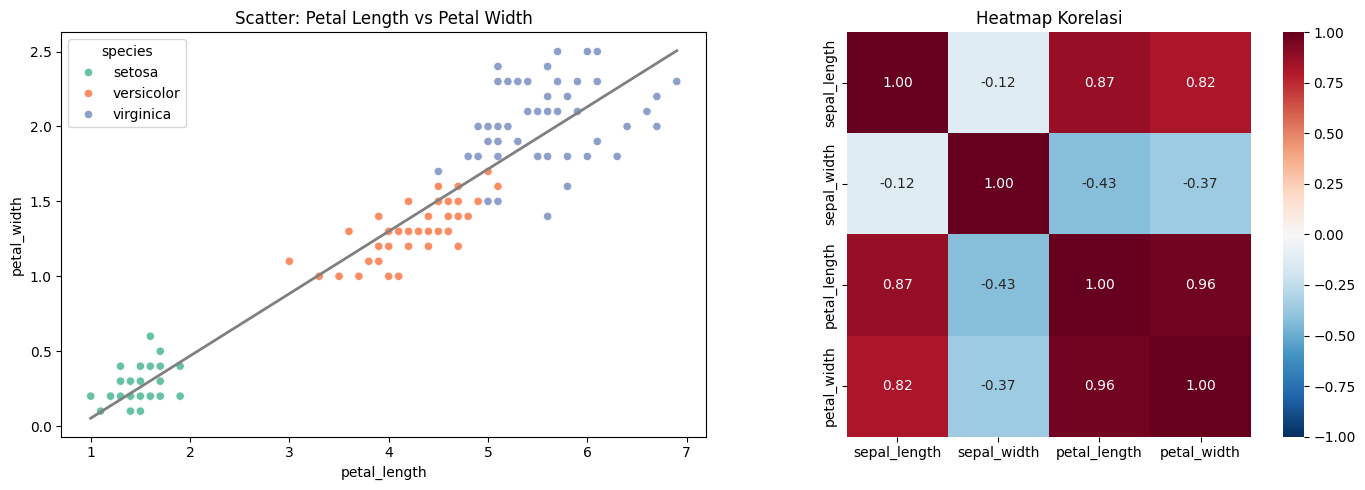

In [19]:
#6. Scatter Plot & Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', palette='Set2', ax=axes[0])
m, b, *_ = stats.linregress(df['petal_length'], df['petal_width'])
xr = np.linspace(df['petal_length'].min(), df['petal_length'].max(), 100)
axes[0].plot(xr, m * xr + b, color='gray', linewidth=2)
axes[0].set_title('Scatter: Petal Length vs Petal Width')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

# Kesimpulan

## Apa yang Dipelajari
Mempelajari statistik deskriptif (mean, median, std, skewness) dan visualisasi EDA menggunakan Matplotlib dan Seaborn pada dataset Iris.

## Temuan Utama
Petal length dan petal width adalah fitur paling diskriminatif antar spesies Iris. Scatter plot dan heatmap korelasi membuktikan bahwa setosa dapat dipisahkan secara linear dari dua spesies lainnya.

## Keterbatasan & Pertanyaan
Dataset Iris terlalu bersih dan terstruktur, tidak merepresentasikan tantangan data nyata. Pertanyaan: bagaimana jika distribusi data tidak normal, apakah uji statistik parametrik masih valid?